# WESM Price Prediction - Model 3: Multiclass Logistic Regression


## Setup and Loading


This notebook trains a Multiclass Logistic Regression model to classify each 5-minute interval into one of three price states.

### Why multiclass?

Negative GWAP events are caused by over-generation, where too much supply causes prices to fall to zero or below. Positive spikes are caused by scarcity, where too little supply relative to demand pushes prices up sharply. These are different market conditions with different characteristics, so separating them into different classes lets the model learn each independently.

The three classes are:
- **0 - Normal**: GWAP in (0, 5,000]
- **1 - Negative**: GWAP <= 0 (over-generation events)
- **2 - Positive Spike**: GWAP > 5,000 (scarcity events)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(df.head())


Dataset Shape: (34535, 19)
Date Range: 2025-10-29 00:05:00 to 2026-02-26 00:00:00
             datetime       GWAP  energy_demand_mw  energy_supply_mw  \
0 2025-10-29 00:05:00  2258.5866           9504.45           9705.25   
1 2025-10-29 00:10:00  2913.4257           9483.49           9648.89   
2 2025-10-29 00:15:00  2883.5764           9434.35           9627.98   
3 2025-10-29 00:20:00  2888.6233           9417.62           9614.19   
4 2025-10-29 00:25:00  2887.9553           9379.48           9575.17   

   energy_shortage_mw  reserve_demand_mw  reserve_supply_mw  outage_count  \
0             -200.80             1428.0             1428.0           4.0   
1             -165.40             1428.0             1428.0           4.0   
2             -193.63             1428.0             1428.0           4.0   
3             -196.57             1428.0             1428.0           4.0   
4             -195.69             1428.0             1428.0           4.0   

   GWAP_Lag_1  GWAP_La

---


## I. Target Engineering


The target variable `price_class` is created from `GWAP` with three classes:

| Class | Label | GWAP Range | Economic Meaning |
|---|---|---|---|
| 0 | Normal | 0 < GWAP <= 5,000 | Typical market conditions |
| 1 | Negative | GWAP <= 0 | Over-generation, prices at or below zero |
| 2 | Positive Spike | GWAP > 5,000 | Scarcity, prices more expensive than usual |

**Note:** GWAP = 0 is assigned to the Negative class since a price of exactly zero still signals over-generation and is not a normal market condition.

In [2]:
def assign_class(gwap):
    if gwap <= 0:
        return 1  # Negative
    elif gwap > 5000:
        return 2  # Positive Spike
    else:
        return 0  # Normal

df['price_class'] = df['GWAP'].apply(assign_class)

counts = df['price_class'].value_counts().sort_index()
labels = {0: 'Normal', 1: 'Negative', 2: 'Positive Spike'}
print(f"{'Class':<20} | {'Count':>8} | {'% of Total':>10}")
print("-" * 44)
for cls, count in counts.items():
    print(f"{labels[cls]:<20} | {count:>8} | {count/len(df)*100:>9.1f}%")


Class                |    Count | % of Total
--------------------------------------------
Normal               |    26348 |      76.3%
Negative             |     2539 |       7.4%
Positive Spike       |     5648 |      16.4%


---


## II. Feature Selection


Same 16 base features as all other notebooks. Refer to Notebook 3 for the full justification table.

**Note:** `energy_shortage_mw` remains excluded for the same perfect multicollinearity reason. The target is now `price_class` (0, 1, or 2) instead of `GWAP`.

In [3]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "price_class"

print(f"Number of features: {len(FEATURE_COLS)}")


Number of features: 16


---


## III. Train / Validation / Test Split


Same 60/20/20 chronological split as the other notebooks. The class rate per split is also checked since class distributions vary across time periods, which can affect how well the validation metrics reflect real generalization.

In [4]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

for split_df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    counts = split_df['price_class'].value_counts().sort_index()
    total  = len(split_df)
    neg_pct = counts.get(1, 0) / total * 100
    pos_pct = counts.get(2, 0) / total * 100
    print(f"{name:<6}: {total:>6} rows | Normal: {100-neg_pct-pos_pct:.1f}% | Negative: {neg_pct:.1f}% | Positive Spike: {pos_pct:.1f}%")


Train :  20721 rows | Normal: 73.2% | Negative: 6.0% | Positive Spike: 20.8%
Val   :   6907 rows | Normal: 80.5% | Negative: 12.0% | Positive Spike: 7.5%
Test  :   6907 rows | Normal: 81.5% | Negative: 6.6% | Positive Spike: 11.8%


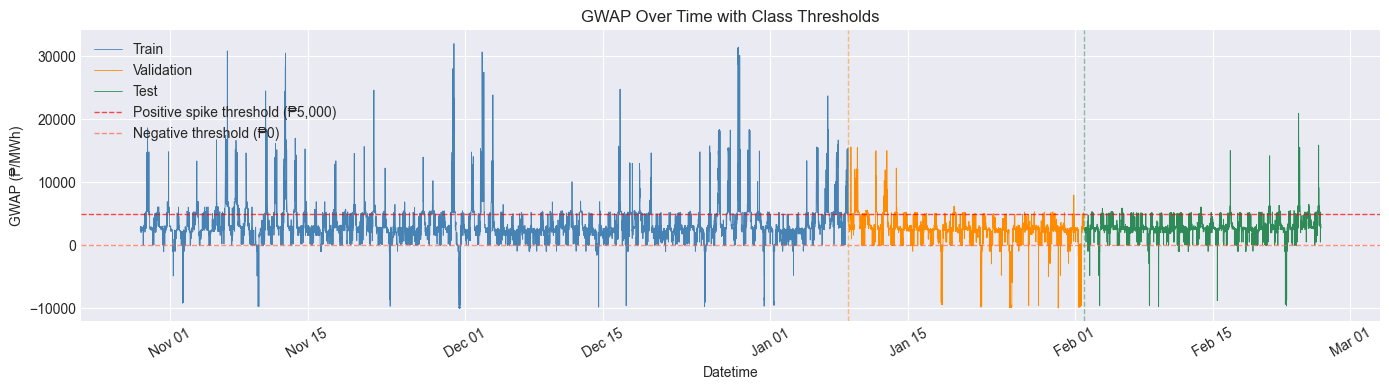

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train_df["datetime"], train_df["GWAP"], color="steelblue",  label="Train",      linewidth=0.6)
ax.plot(val_df["datetime"],   val_df["GWAP"],   color="darkorange", label="Validation", linewidth=0.6)
ax.plot(test_df["datetime"],  test_df["GWAP"],  color="seagreen",   label="Test",       linewidth=0.6)

ax.axhline(5000, color="red",    linestyle="--", linewidth=1, alpha=0.7, label="Positive spike threshold (₱5,000)")
ax.axhline(0,    color="tomato", linestyle="--", linewidth=1, alpha=0.7, label="Negative threshold (₱0)")
ax.axvline(train_df["datetime"].max(), color="darkorange", linestyle="--", linewidth=1, alpha=0.5)
ax.axvline(val_df["datetime"].max(),   color="seagreen",   linestyle="--", linewidth=1, alpha=0.5)

ax.set_title("GWAP Over Time with Class Thresholds")
ax.set_xlabel("Datetime")
ax.set_ylabel("GWAP (₱/MWh)")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [6]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]


---


## IV. Feature Scaling


Same standardization as the other notebooks. The scaler is **fit only on the training set** and applied to validation and test to avoid data leakage.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train mean: {X_train_scaled.mean(axis=0).mean():.6f}")
print(f"Train std : {X_train_scaled.std(axis=0).mean():.6f}")


Train mean: -0.000000
Train std : 1.000000


---


## V. Model Training


Same two-model protocol as the other notebooks:

1. **`clf`** - trained on the training set only. Used to evaluate train and validation performance.
2. **`clf_final`** - retrained on the combined train + validation set. Used for final test evaluation.

`class_weight='balanced'` accounts for class imbalance across all three classes. `solver='lbfgs'` is used since it supports multinomial loss natively and fits all three classes simultaneously using softmax.

In [8]:
clf = LogisticRegression(
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Refit scaler on train+val for the final model
scaler_final = StandardScaler()
X_trainval_raw = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

X_trainval_scaled = scaler_final.fit_transform(X_trainval_raw)
X_test_scaled_final = scaler_final.transform(X_test)

clf_final = LogisticRegression(
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
clf_final.fit(X_trainval_scaled, y_trainval)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


---


## VI. Evaluation


For multiclass classification, the evaluation metrics are reported per class and summarized as averages:

- **Precision / Recall / F1 per class**: how well the model handles each class individually.
- **Macro F1**: unweighted average across all three classes. This is the **primary metric** since it treats each class equally and penalizes poor performance on the minority classes (Negative and Positive Spike). A high Weighted F1 can hide poor spike detection if Normal dominates the average.
- **Weighted F1**: average weighted by class size, shown for reference. It is dominated by Normal (76% of data) so it is less informative for this problem.
- **ROC-AUC (one-vs-rest)**: computed for each class against all others, then averaged. Measures how well the model's probability scores separate each class from the rest.

Train and validation are evaluated using `clf`. Test is evaluated using `clf_final`.

In [9]:
CLASS_NAMES = ['Normal', 'Negative', 'Pos. Spike']

def evaluate_multi(model, X, y, label):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)
    report = classification_report(y, y_pred, target_names=CLASS_NAMES, output_dict=True)
    auc    = roc_auc_score(y, y_prob, multi_class='ovr', average='macro')
    print(f" \n{label.upper()}\n")
    print(classification_report(y, y_pred, target_names=CLASS_NAMES))
    print(f"  Macro F1    : {report['macro avg']['f1-score']:.4f}")
    print(f"  ROC-AUC     : {auc:.4f}")
    return y_pred, y_prob

_, _                      = evaluate_multi(clf,       X_train_scaled,     y_train, "Train")
_, _                      = evaluate_multi(clf,       X_val_scaled,       y_val,   "Validation")
y_test_pred, y_test_prob  = evaluate_multi(clf_final, X_test_scaled_final, y_test,  "Test")

 
TRAIN

              precision    recall  f1-score   support

      Normal       0.97      0.81      0.88     15161
    Negative       0.40      0.89      0.56      1248
  Pos. Spike       0.77      0.95      0.85      4312

    accuracy                           0.84     20721
   macro avg       0.71      0.88      0.76     20721
weighted avg       0.90      0.84      0.86     20721

  Macro F1    : 0.7627
  ROC-AUC     : 0.9648
 
VALIDATION

              precision    recall  f1-score   support

      Normal       0.98      0.84      0.90      5557
    Negative       0.62      0.90      0.74       832
  Pos. Spike       0.53      0.93      0.68       518

    accuracy                           0.86      6907
   macro avg       0.71      0.89      0.77      6907
weighted avg       0.90      0.86      0.87      6907

  Macro F1    : 0.7729
  ROC-AUC     : 0.9653
 
TEST

              precision    recall  f1-score   support

      Normal       0.96      0.87      0.91      5630
    Ne

The model performs well across all three classes on the test set (Macro F1: 0.764, ROC-AUC: 0.947).

For the two spike classes, recall is the more important metric since missing an extreme event is more costly than a false alarm (although may be debatable depending on end user). Positive Spike has good recall at 0.87 (F1: 0.72), likely because scarcity events have consistent feature characteristics. Negative is harder with recall of 0.77 (F1: 0.66) probably because over-generation events can occur under market conditions that otherwise look normal, making them more difficult to distinguish.

For Normal, precision matters more because a low precision on Normal would mean the model is mistaking actual spikes as normal intervals, which is the costly error. At 0.96, this is controlled well.

---


## VII. Visualizations


### Confusion Matrix


The 3x3 confusion matrix shows how often each class is correctly classified and which classes are confused with each other.

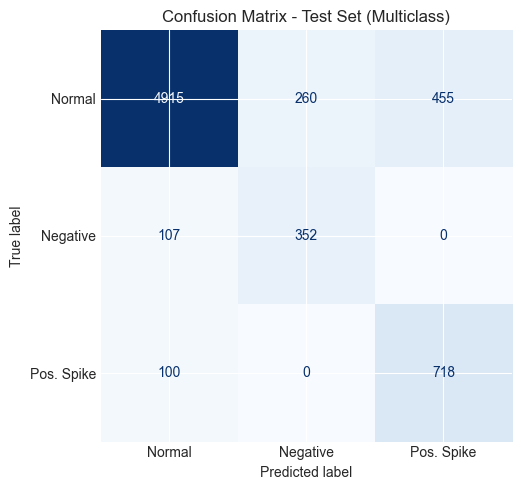

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Matrix - Test Set (Multiclass)")
plt.tight_layout()
plt.show()


Normal has the most total misclassifications (714) but this is mostly because it is the largest class; additionally, its recall of 0.873 is strong. Negative (107 missed) and Positive Spike (103 missed) are the harder minority classes, with Negative showing more confusion with Normal than Positive Spike does.

### Predicted Probabilities by Class


For each test interval, the model outputs three probabilities (one per class) that sum to 1. Plotting these against actual GWAP shows whether the model assigns high probability to the correct class in the right GWAP regions.

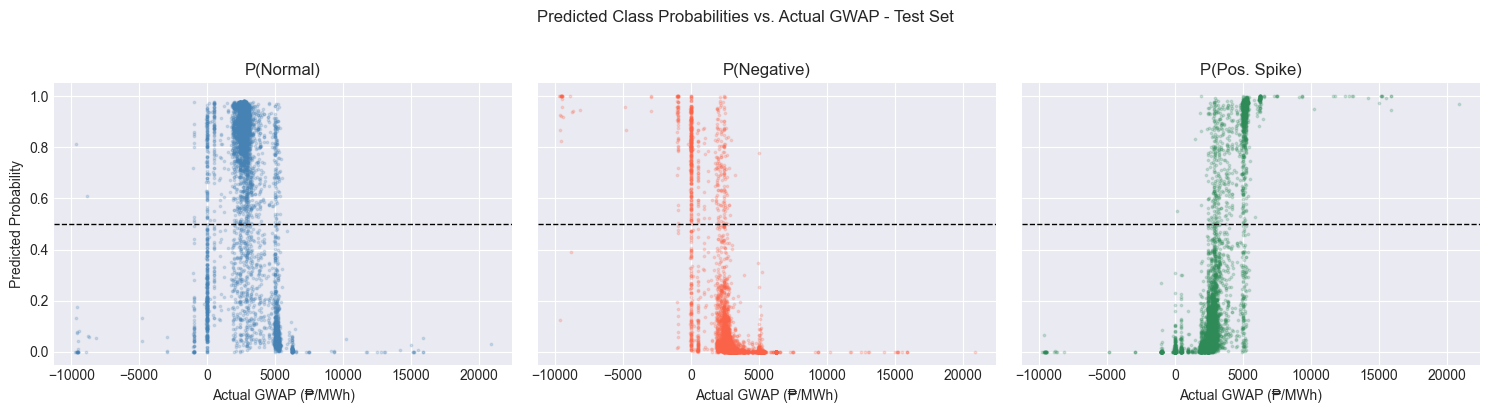

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ['steelblue', 'tomato', 'seagreen']

for idx, (cls_idx, cls_name) in enumerate(zip([0, 1, 2], CLASS_NAMES)):
    axes[idx].scatter(
        test_df['GWAP'].values,
        y_test_prob[:, cls_idx],
        alpha=0.2, s=3, color=colors[idx]
    )
    axes[idx].axhline(0.5, color='black', linestyle='--', linewidth=1)
    axes[idx].set_title(f"P({cls_name})")
    axes[idx].set_xlabel("Actual GWAP (₱/MWh)")
    if idx == 0:
        axes[idx].set_ylabel("Predicted Probability")

plt.suptitle("Predicted Class Probabilities vs. Actual GWAP - Test Set", y=1.02)
plt.tight_layout()
plt.show()


---


## VIII. Feature Coefficients


In multiclass logistic regression, there is one set of coefficients per class. A positive coefficient for a class means that feature increases the probability of being assigned to that class. Coefficients are taken from `clf_final`.

In [12]:
coef_df = pd.DataFrame(
    clf_final.coef_,
    index=['Normal', 'Negative', 'Pos. Spike'],
    columns=FEATURE_COLS
).T

print(coef_df.to_string())


                     Normal  Negative  Pos. Spike
energy_demand_mw  -0.629592 -0.526172    1.155764
energy_supply_mw   0.671680 -0.087214   -0.584466
reserve_demand_mw -0.207102  0.067396    0.139706
reserve_supply_mw  0.027341 -0.051059    0.023718
outage_count       0.013431 -0.230628    0.217197
GWAP_Lag_1        -0.125413 -3.820483    3.945896
GWAP_Lag_12        0.076748 -1.046882    0.970134
GWAP_Lag_288      -0.010042 -0.632796    0.642838
hour_sin          -0.012513  0.281848   -0.269335
hour_cos           0.353781 -0.720583    0.366802
dow_1              0.045082  0.204178   -0.249260
dow_2              0.024443  0.190037   -0.214480
dow_3              0.054559  0.254982   -0.309542
dow_4              0.083667  0.192263   -0.275930
dow_5              0.078085  0.187344   -0.265428
dow_6              0.079704  0.077411   -0.157115


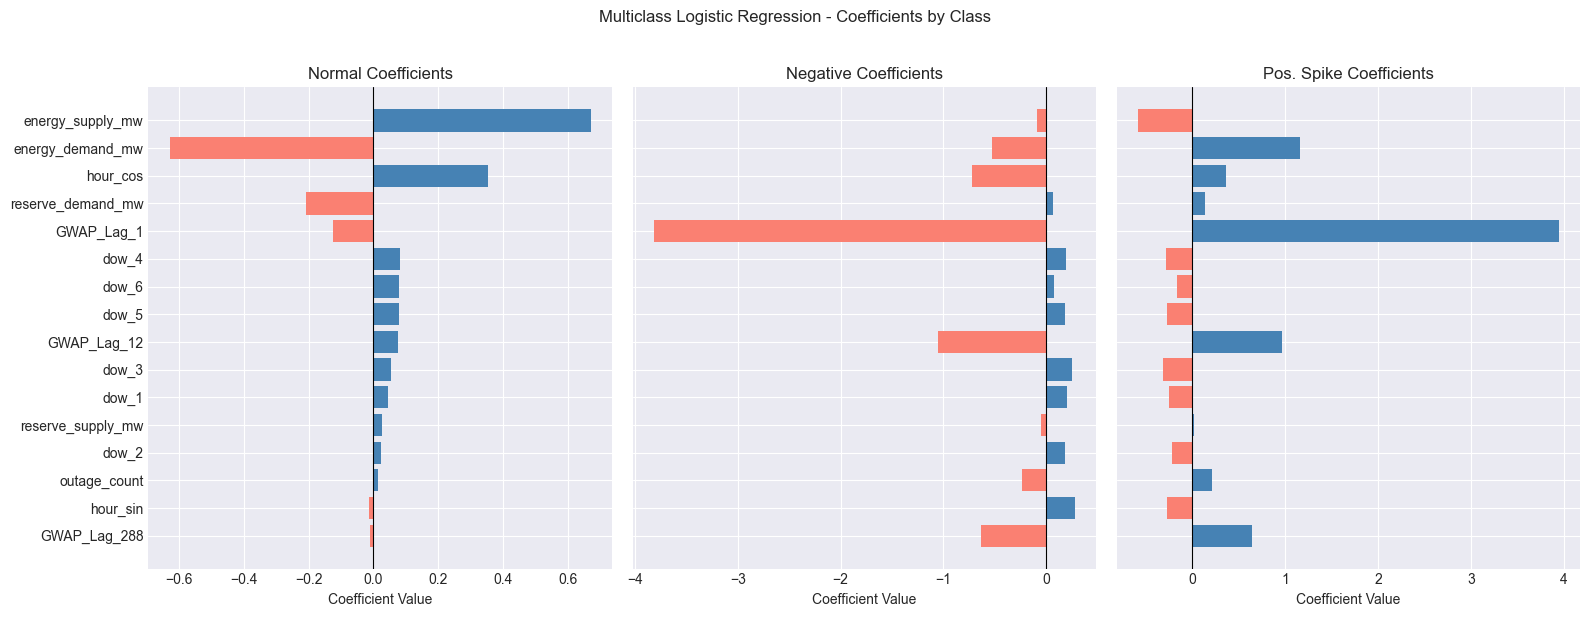

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
colors_pos = ['steelblue', 'tomato', 'seagreen']

for idx, cls_name in enumerate(['Normal', 'Negative', 'Pos. Spike']):
    coefs = coef_df[cls_name].sort_values(key=abs, ascending=True)
    bar_colors = ['steelblue' if c >= 0 else 'salmon' for c in coefs]
    axes[idx].barh(coefs.index, coefs.values, color=bar_colors)
    axes[idx].axvline(0, color='black', linewidth=0.8)
    axes[idx].set_title(f"{cls_name} Coefficients")
    axes[idx].set_xlabel("Coefficient Value")

plt.suptitle("Multiclass Logistic Regression - Coefficients by Class", y=1.02)
plt.tight_layout()
plt.show()


The coefficient patterns are consistent with economic intuition.

- **GWAP_Lag_1 is the strongest predictor for both spike classes but in opposite directions (-3.94 for Negative, +4.07 for Positive Spike)**. This makes sense because if the price 5 minutes ago was already very low, the market is likely in an over-generation state. If it was very high, scarcity is the likely driver.
- **Energy demand and supply flip between classes**. High demand strongly increases Positive Spike probability (+1.24) and pushes against Normal (-0.69), while supply does the opposite. This directly reflects the underlying economics of each event type.
- **Hour of day (hour_cos) is negative for Negative (-0.72) and positive for Positive Spike (+0.37)**, which suggests negative events tend to cluster at night and positive spikes during peak daytime hours.

---


**Note:** We first did a binary classifier but it was quite bad (F1 = 0.494) so we restructured the model to instead do multiclassification.